In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandapower as pp
from pathlib import Path
import json
import numba
import time

In [17]:

KABEL_PATH  = "data\\netz_excels\\kabel_excel.xlsx"
KNOTEN_PATH = "data\\netz_excels\\knoten_excel.xlsx"
PARAMS_PATH = "data\\netz_excels\\kabel_parameter.csv"


kabel  = pd.read_excel(KABEL_PATH, index_col=0)
knoten = pd.read_excel(KNOTEN_PATH, index_col=0)
params = pd.read_csv(PARAMS_PATH)


In [18]:
net = pp.create_empty_network(f_hz=50, sn_mva=10)

for idx, row in knoten.iterrows():
    pp.create_bus(net, vn_kv=0.4, name=row["IDENTNUMME"], index=idx)

print(net.bus)


          name  vn_kv type  zone  in_service   geo
0   6B0402-302    0.4    b  None        True  None
1   6B0402-041    0.4    b  None        True  None
3   6B0402-125    0.4    b  None        True  None
4   6B4100-003    0.4    b  None        True  None
5   6B0402-209    0.4    b  None        True  None
6   6B0402-043    0.4    b  None        True  None
7   6B0402-037    0.4    b  None        True  None
8   6B0402-017    0.4    b  None        True  None
9   6B0402-272    0.4    b  None        True  None
10  6B0402-282    0.4    b  None        True  None
11  6B0402-318    0.4    b  None        True  None
12  6B0402-320    0.4    b  None        True  None
13  6B0402-324    0.4    b  None        True  None
14  6B0402-328    0.4    b  None        True  None
15  6B0402-332    0.4    b  None        True  None
16  6B0402-334    0.4    b  None        True  None
17  6B0402-336    0.4    b  None        True  None
19  6B0402-270    0.4    b  None        True  None
20  6B0402-103    0.4    b  Non

In [19]:
netzstation = knoten[knoten["KNOTENTYP"] == "NETZSTATION"]
slack_idx = netzstation.index[0]

pp.create_ext_grid(
    net,
    bus  = slack_idx,
    vm_pu = 1.0,
    name = knoten.loc[slack_idx, "IDENTNUMME"]
)

print(net.ext_grid)

         name  bus  vm_pu  va_degree  slack_weight  in_service  controllable
0  6B0402-041    1    1.0        0.0           1.0        True         False


In [20]:
params_dict = {
    (row["kabeltyp"], row["adern"], row["querschnitt_mm2"]): (
        row["r_ohm_per_km"],
        row["x_ohm_per_km"],
        row["c_nf_per_km"],
        row["max_i_ka"]
    )
    for _, row in params.iterrows()
}

# Leitungen anlegen
keine_params = []

for idx, row in kabel.iterrows():
    key = (row["KABELTYP"], row["ADERN"], row["QUERSCHNIT"])

    if key not in params_dict:
        keine_params.append(key)
        continue

    r, x, c, imax = params_dict[key]

    pp.create_line_from_parameters(
        net,
        from_bus     = row["start_bus"],
        to_bus       = row["end_bus"],
        length_km    = row["length_m"] / 1000,
        r_ohm_per_km = r,
        x_ohm_per_km = x,
        c_nf_per_km  = c,
        max_i_ka     = imax,
        name         = f"Kabel_{idx}"
)

if keine_params:
    print(f"⚠ Keine Parameter für: {set(keine_params)}")
else:
    print(net.line)



        name std_type  from_bus  to_bus  length_km  r_ohm_per_km  \
0    Kabel_0     None         0      33   0.020941         1.150   
1    Kabel_1     None         1      20   0.031199         0.206   
2    Kabel_3     None         3       1   0.018862         0.206   
3    Kabel_4     None         1      26   0.008117         0.206   
4    Kabel_5     None         4       1   0.120900         0.206   
5    Kabel_6     None         5      22   0.062805         0.443   
6    Kabel_7     None         7      35   0.021956         0.253   
7    Kabel_8     None         1       6   0.034085         0.206   
8    Kabel_9     None         9      31   0.017520         1.870   
9   Kabel_10     None        10      35   0.076792         0.868   
10  Kabel_11     None        11      36   0.061731         0.868   
11  Kabel_12     None        12      37   0.017808         0.320   
12  Kabel_13     None        13      38   0.025279         0.868   
13  Kabel_14     None        14      38   0.0126

In [21]:
datetime_index = pd.date_range(start="2018-01-01", end="2018-12-31 23:00", freq="h")

#Platzhalter DF
with open("data/gebaudelasten/gebauedelasten.json", "r") as f:
    load_data = json.load(f)

load_df = pd.DataFrame(load_data, index=datetime_index)

#print(load_df.shape)
#print(load_df.head())

t = 0
timestep = load_df.iloc[t]

for col in load_df.columns:
    bus_idx = int(col.split("_")[1])
    p_mw   = timestep[col] / 1000  # kW -> MW

    pp.create_load(
        net,
        bus    = bus_idx,
        p_mw   = p_mw,
        q_mvar = 0.0,
        name   = f"Last_{bus_idx}"
    )

print(net.load[["name", "bus", "p_mw"]])


       name  bus      p_mw
0    Last_4    4  0.003827
1    Last_8    8  0.000056
2    Last_9    9  0.000044
3   Last_10   10  0.000100
4   Last_12   12  0.000570
5   Last_13   13  0.000239
6   Last_14   14  0.000225
7   Last_15   15  0.001971
8   Last_16   16  0.001076
9   Last_17   17  0.000048
10  Last_19   19  0.012500
11  Last_24   24  0.000052
12  Last_30   30  0.000047
13  Last_32   32  0.000055
14  Last_35   35  0.000921


In [49]:
# Spitzenlast finden und Lastfluss berechnen
gesamtlast = load_df.sum(axis=1)  # Summe aller Profile pro Zeitschritt
t_peak = gesamtlast.idxmax()      # Zeitpunkt der maximalen Gesamtlast

print(f"Spitzenlast-Zeitpunkt: {t_peak}")
print(f"Gesamtlast: {gesamtlast[t_peak]:.2f} kW")

# Spitzenlast-Zeitschritt
timestep = load_df.loc[t_peak]

# Lasten im Netz aktualisieren
for col in load_df.columns:
    bus_idx = int(col.split("_")[1])
    p_mw    = timestep[col] / 1000  # kW -> MW

    net.load.loc[net.load["bus"] == bus_idx, "p_mw"] = p_mw

# Lastfluss berechnen
pp.runpp(net, algorithm="nr", numba=False)

print(f"✅ Lastfluss konvergiert für {t_peak}")
print(f"\nBus-Spannungen:")
print(net.res_bus[["vm_pu"]].sort_values("vm_pu"))
print(f"\nLeitungsauslastung:")
print(net.res_line[["loading_percent"]].sort_values("loading_percent", ascending=False))

Spitzenlast-Zeitpunkt: 2018-11-16 21:00:00
Gesamtlast: 167.44 kW
✅ Lastfluss konvergiert für 2018-11-16 21:00:00

Bus-Spannungen:
       vm_pu
4   0.990420
34  0.993019
6   0.996991
17  0.997114
24  0.997342
10  0.997353
23  0.997425
16  0.997449
22  0.997451
27  0.997460
8   0.997495
29  0.997495
41  0.997495
36  0.997495
11  0.997495
39  0.997699
15  0.997721
13  0.997862
28  0.997901
14  0.997917
5   0.997928
38  0.997995
9   0.998227
32  0.998394
0   0.998584
12  0.998620
31  0.998637
37  0.998699
44  0.998831
40  0.998831
35  0.998877
33  0.998887
30  0.998929
43  0.998938
7   0.999044
19  0.999297
20  0.999644
1   1.000000
26  1.000000
3   1.000000
25  1.000000

Leitungsauslastung:
    loading_percent
29        27.458879
30        27.458879
7         27.458879
4         24.658550
42         6.244728
41         5.354034
40         4.636064
16         3.860644
1          3.553962
35         3.553962
15         3.234285
9          3.199659
8          2.755474
0          2.617373
43 

In [ ]:
# Schrittweite in Stunden angeben

SCHRITTWEITE = 1

zeitschritte = load_df.iloc[::SCHRITTWEITE]

# Ergebnisse speichern
res_vm   = {}  # Busspannungen
res_load = {}  # Leitungsauslastung

start = time.time()

for ts, row in zeitschritte.iterrows():
    # Lasten aktualisieren
    for col in load_df.columns:
        bus_idx = int(col.split("_")[1])
        net.load.loc[net.load["bus"] == bus_idx, "p_mw"] = row[col] / 1000

    # Lastfluss
    pp.runpp(net, algorithm="nr", numba=False)

    # Ergebnisse speichern
    res_vm[ts]   = net.res_bus["vm_pu"].copy()
    res_load[ts] = net.res_line["loading_percent"].copy()

dauer = time.time() - start


Zu berechnende Zeitschritte: 8760
Dauer: 369.4s für 8760 Zeitschritte
Hochrechnung auf 8760 Zeitschritte: 6.2 Minuten


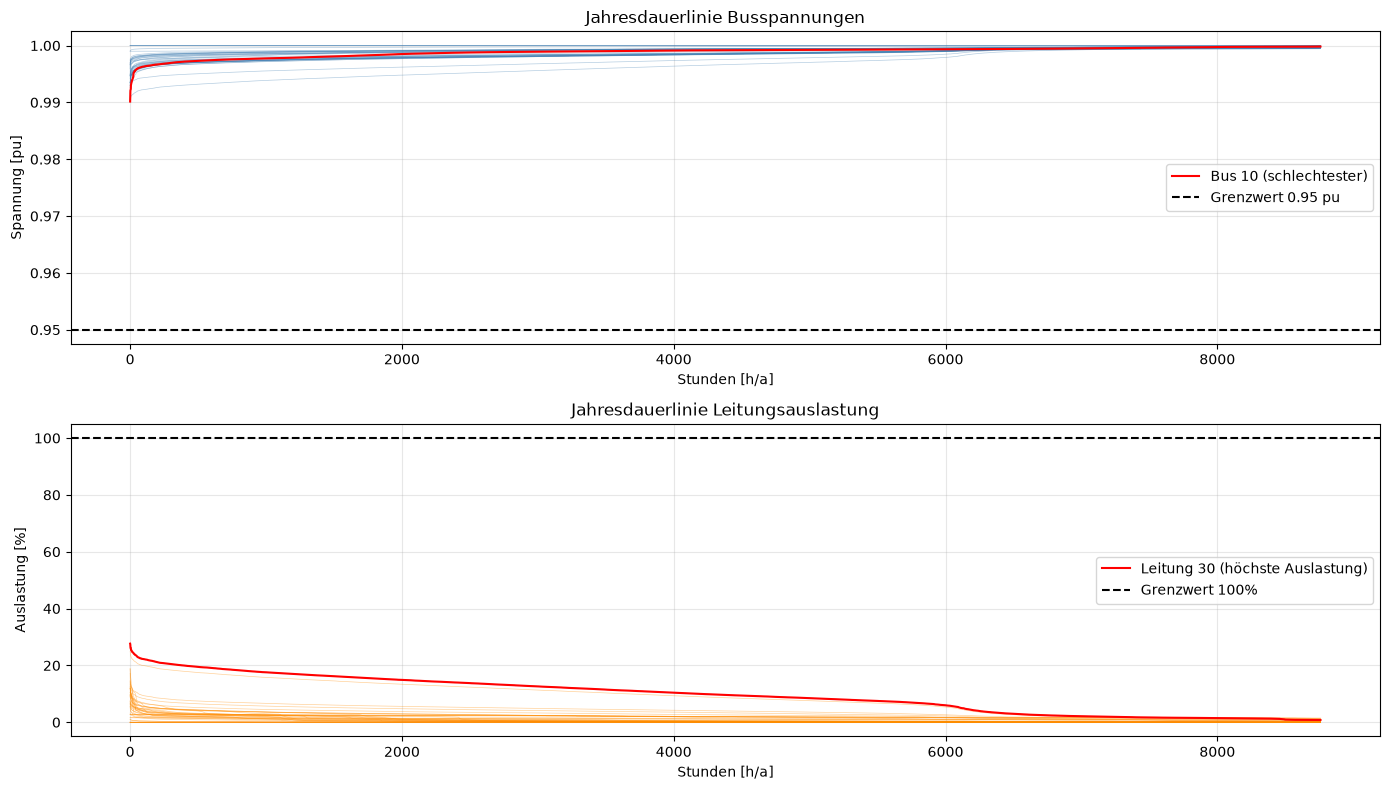

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# --- Jahresdauerlinie Busspannungen ---
for bus in vm_pu_df.columns:
    sortiert = vm_pu_df[bus].sort_values(ascending=True).values
    axes[0].plot(range(8760), sortiert, color="steelblue", linewidth=0.5, alpha=0.4)

# Schlechtester Bus hervorheben
schlechtester = vm_pu_df.min().idxmin()
sortiert_worst = vm_pu_df[schlechtester].sort_values(ascending=True).values
axes[0].plot(range(8760), sortiert_worst, color="red", linewidth=1.5, label=f"Bus {schlechtester} (schlechtester)")
axes[0].axhline(0.95, color="black", linestyle="--", label="Grenzwert 0.95 pu")
axes[0].set_xlabel("Stunden [h/a]")
axes[0].set_ylabel("Spannung [pu]")
axes[0].set_title("Jahresdauerlinie Busspannungen")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Jahresdauerlinie Leitungsauslastung ---
for line in loading_df.columns:
    sortiert = loading_df[line].sort_values(ascending=False).values
    axes[1].plot(range(8760), sortiert, color="darkorange", linewidth=0.5, alpha=0.4)

# Stärkste Leitung hervorheben
stärkste = loading_df.max().idxmax()
sortiert_worst = loading_df[stärkste].sort_values(ascending=False).values
axes[1].plot(range(8760), sortiert_worst, color="red", linewidth=1.5, label=f"Leitung {stärkste} (höchste Auslastung)")
axes[1].axhline(100, color="black", linestyle="--", label="Grenzwert 100%")
axes[1].set_xlabel("Stunden [h/a]")
axes[1].set_ylabel("Auslastung [%]")
axes[1].set_title("Jahresdauerlinie Leitungsauslastung")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()